# 2.11.1 Random Forest

## Setup

In [ ]:
import numpy as np
import pandas as pd

import re
import unicodedata
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

import requests
from functools import reduce
from bs4 import BeautifulSoup
from multiprocessing import Pool

import plotly.io as pio
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_validate, RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score
from sklearn.pipeline import Pipeline

import warnings
import session_info
from scipy import stats
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
from sklearn import set_config

sns.set_style('dark')
pd.set_option("display.max_columns", 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pio.templates.default = "plotly_dark"
set_config(transform_output="pandas")
set_config(display='diagram')
warnings.filterwarnings("ignore")

%matplotlib inline

# Directorio de datos
dir_data = '../03_Data/'

In [ ]:
def get_cv_scores_report_classification(estimator, X, y, n_splits):
    cv_scores = cross_validate(
                    estimator = estimator,
                    X         = X,
                    y         = y,
                    scoring   = {
                                'precision': make_scorer(precision_score, average='weighted'),
                                'recall': make_scorer(recall_score, average='weighted'),
                                'f1': make_scorer(f1_score, average='weighted')
                                },
                    cv        = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=5, random_state=333),
                )

    # Convertir el diccionario a dataframe para facilitar la visualización
    cv_scores = pd.DataFrame(cv_scores)
    print(f"Precision en CV: mean {cv_scores.test_precision.mean():.2f}, std {cv_scores.test_precision.std():.2f}")
    print(f"Recall en CV: mean {cv_scores.test_recall.mean():.2f}, std {cv_scores.test_recall.std():.2f}")
    print(f"F1 en CV: mean {cv_scores.test_f1.mean():.2f}, std {cv_scores.test_f1.std():.2f}")
def scrape(url):
    req = requests.get(url)
    return url, req.text
def make_pool(func, params, threads):
    pool = Pool(threads)
    data = pool.map(func, params)
    pool.close()
    pool.join()
    del pool
    return data
def get_data(soup):
    title = soup.find_all("h1")[0].text if len(soup.find_all("h1")) > 0 else ''
    subtitles = soup.find_all("h2")
    channel = subtitles[0].text if len(subtitles) > 0 else ''
    images = len(soup.find_all("img"))
    videos = len(soup.find_all("iframe"))
    paragraphs = soup.find_all("article")
    text = "\n".join([x.text for x in paragraphs])
    return title, len(subtitles), channel, images, videos, len(paragraphs), text
def text_features(url, text):
    sid = SentimentIntensityAnalyzer()
    sentences = sent_tokenize(text)
    polarities = pd.DataFrame(map(sid.polarity_scores, sentences))
    words = pd.DataFrame(map(len, map(word_tokenize, sentences)))
    sentences_data = polarities.join(words).rename(columns={0: "n_words"})
    sentences_data["url"] = url
    return sentences_data
def clean_text(text, pattern="[^a-zA-Z ]"):
    cleaned_text = unicodedata.normalize('NFD', text).encode('ascii', 'ignore')
    cleaned_text = re.sub(pattern, "", cleaned_text.decode("utf-8"), flags=re.UNICODE)
    cleaned_text = u' '.join(cleaned_text.lower().split())
    return cleaned_text
def generate_wordcloud(text, output_name="./wordcloud.png"):
    wc = WordCloud(background_color="black", width=800, height=800,
                   random_state=21, max_font_size=110).generate(text)
    plt.figure(figsize=(10, 10))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis('off')
    plt.savefig(output_name)
    plt.show()

In [ ]:
session_info.show()

## 2.11.1. Random Forest

### Contexto

**Árbol de Decisión**

Un árbol de decisión es una estructura de flujo donde:
- Cada nodo interno denota una prueba en un atributo.
- Cada rama representa un resultado de la prueba.
- Cada nodo hoja (nodo terminal) tiene una etiqueta (clase).

La idea es partir el espacio de características en regiones (para regresión) o en clases discretas (para clasificación).

Formalmente, el proceso de crecimiento del árbol se basa en una función de impureza $ I $, que puede ser entropía, índice de Gini, o error de clasificación. El objetivo es minimizar la impureza en cada paso. Si $ C_t $ es el conjunto de datos en nodo $ t $ y $ p(i|t) $ es la proporción de clase $ i $ en $ C_t $.

**Bosque Aleatorio**

**Bosque Aleatorio o Random Forest** es un método de ensamblaje que crea un **bosque** de árboles de decisión durante el entrenamiento. Durante la predicción, Random Forest agrega las predicciones de cada árbol para producir el resultado final.

Formalmente, si $ B $ es el número de árboles en el bosque y $ h(x, \Theta_k) $ es la predicción del árbol $ k $ con parámetros $ \Theta_k $ para una entrada $ x $, entonces para:

**Regresión**:
$$ H(x) = \frac{1}{B} \sum_{k=1}^{B} h(x, \Theta_k) $$

**Clasificación**:
$$ H(x) = \text{moda} \{ h(x, \Theta_1), h(x, \Theta_2), \ldots, h(x, \Theta_B) \} $$

**Peculiaridades en el entrenamiento:**

1. **Bootstrap Aggregating (Bagging)**: Cada árbol se entrena en un subconjunto de datos seleccionado con reemplazo (bootstrap sample) del conjunto de datos original.

1.1 **Bootstrap**

Supongamos que se tiene un lago con un número desconocido de peces. Queremos estimar cuántos peces hay en total, pero no podemos simplemente contarlos a todos. Entonces, hacemos lo siguiente:

1. Capturamos una muestra de peces (por ejemplo, 100 peces) y marcas a cada uno con una etiqueta.
2. Luego, los devolvemos al lago.
3. Después de darles tiempo para mezclarse con los otros peces, volvamos a capturar otra muestra (por ejemplo, 100 peces nuevamente).
4. Contamos cuántos peces en esta segunda muestra están marcados.

Si capturamos una gran proporción de peces marcados en la segunda muestra, podríamos inferir que el lago no tiene muchos más peces de los que ya has marcado. Pero si solo capturas unos pocos peces marcados, probablemente hay muchos más peces en el lago que aún no has visto.

Para el bootstrapping, en lugar de hacer esta operación una sola vez, la repetimos muchas veces (re-muestreando con reemplazo) y observamos la distribución de los resultados:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos un lago con un número aleatorio de peces entre 1000 y 2000
num_peces_real = np.random.randint(1000, 2000)

# Creamos una lista de peces donde cada pez está representado por un número (su ID)
lago = list(range(num_peces_real))

# Capturamos y marcamos una muestra de 100 peces
muestra_marcada = np.random.choice(lago, 100, replace=False)

# Vemos cuántos peces hay realmente y cuántos hemos marcado
num_peces_real, len(muestra_marcada)


(1565, 100)

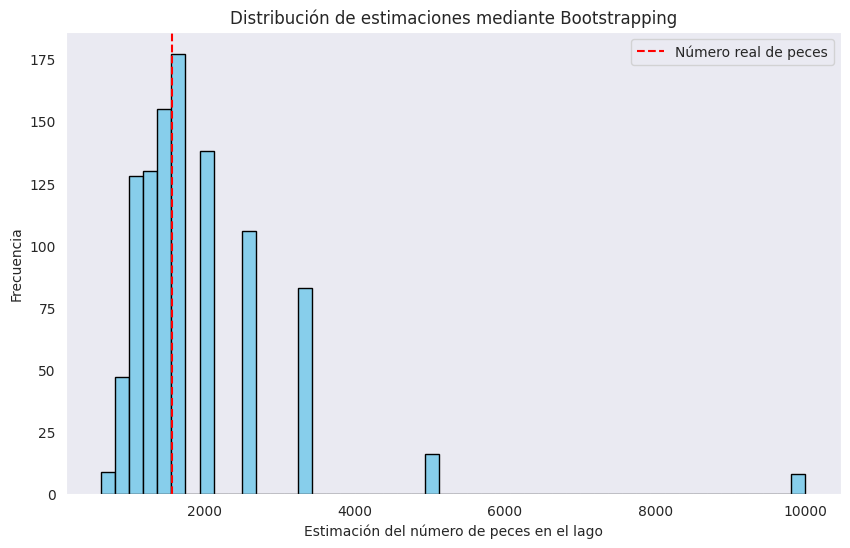

In [ ]:
# Realizamos el bootstrapping

num_simulaciones = 1000
estimaciones = []

for _ in range(num_simulaciones):
    # Capturamos otra muestra de 100 peces
    nueva_muestra = np.random.choice(lago, 100, replace=False)

    # Contamos cuántos de estos peces están marcados
    num_marcados = len(set(nueva_muestra) & set(muestra_marcada))

    # Estimamos el total de peces en el lago usando la proporción
    # Si x peces de 100 están marcados, estimamos que hay 100 * (100 / x) peces en total
    if num_marcados == 0:  # Evitamos la división por cero
        estimacion = np.nan
    else:
        estimacion = 100 * (100 / num_marcados)
    estimaciones.append(estimacion)

# Visualizamos la distribución de estimaciones
plt.figure(figsize=(10, 6))
plt.hist(estimaciones, bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=num_peces_real, color='r', linestyle='--', label="Número real de peces")
plt.xlabel("Estimación del número de peces en el lago")
plt.ylabel("Frecuencia")
plt.title("Distribución de estimaciones mediante Bootstrapping")
plt.legend()
plt.show()

In [ ]:
# Calculamos el promedio y la mediana de las estimaciones
promedio_estimaciones = np.nanmean(estimaciones)
mediana_estimaciones = np.nanmedian(estimaciones)

promedio_estimaciones, mediana_estimaciones

(1848.4396050845398, 1666.6666666666667)

2. **Selección de Características Aleatorias**: En lugar de buscar la mejor característica al dividir un nodo, se selecciona un subconjunto aleatorio de características y se busca la mejor característica solo dentro de este subconjunto.

Estas dos fuentes de aleatoriedad hacen que los árboles en el bosque sean decorrelacionados, lo que a su vez reduce la varianza del modelo sin aumentar significativamente el sesgo.

**Importancia de Características:**

El bosque aleatorio también proporciona una medida de la importancia de las características al observar cuánto disminuye el rendimiento del modelo cuando se altera el valor de una característica. Formalmente, la importancia de una característica $ j $ se mide como:

$$ \text{Importancia}(j) = \frac{1}{B} \sum_{k=1}^{B} \text{Importancia}_k(j) $$

donde $ \text{Importancia}_k(j) $ es la disminución en la precisión del árbol $ k $ causada por la característica $ j $.

### Ejemplo

#### Manipulación de Datos y AED

In [ ]:
shares = pd.read_csv('../03_Data/OnlineNewsPopularity.csv')

In [ ]:
shares.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg,self_reference_min_shares,self_reference_max_shares,self_reference_avg_sharess,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731,12,219,0.66,1.00,0.82,4,2,1,0,4.68,5,0,1,0,0,0,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,496.00,496.00,496.00,1,0,0,0,0,0,0,0,0.50,0.38,0.04,0.04,0.04,0.52,0.09,0.05,0.01,0.77,0.23,0.38,0.10,0.70,-0.35,-0.60,-0.20,0.50,-0.19,0.00,0.19,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731,9,255,0.60,1.00,0.79,3,1,1,0,4.91,4,0,0,1,0,0,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,0,0,0,0,0,0,0,0.80,0.05,0.05,0.05,0.05,0.34,0.15,0.04,0.02,0.73,0.27,0.29,0.03,0.70,-0.12,-0.12,-0.10,0.00,0.00,0.50,0.00,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731,9,211,0.58,1.00,0.66,3,1,1,0,4.39,6,0,0,1,0,0,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,918.00,918.00,918.00,1,0,0,0,0,0,0,0,0.22,0.03,0.03,0.03,0.68,0.70,0.32,0.06,0.01,0.86,0.14,0.50,0.10,1.00,-0.47,-0.80,-0.13,0.00,0.00,0.50,0.00,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731,9,531,0.50,1.00,0.67,9,0,1,0,4.40,7,0,1,0,0,0,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,0,0,0,0,0,0,0,0.03,0.42,0.49,0.03,0.03,0.43,0.10,0.04,0.02,0.67,0.33,0.39,0.14,0.80,-0.37,-0.60,-0.17,0.00,0.00,0.50,0.00,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731,13,1072,0.42,1.00,0.54,19,19,20,0,4.68,7,0,0,0,0,1,0,0,0.00,0.00,0,0,0.00,0.00,0.00,0.00,545.00,16000.00,3151.16,1,0,0,0,0,0,0,0,0.03,0.03,0.03,0.03,0.89,0.51,0.28,0.07,0.01,0.86,0.14,0.41,0.03,1.00,-0.22,-0.50,-0.05,0.45,0.14,0.05,0.14,505


In [ ]:
shares.columns

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [ ]:
shares.sample()["url"].values[0]

'http://mashable.com/2014/11/17/kobani-isis-explosions/'

In [ ]:
# Calculando el número promedio de veces que se compartió algo por día (o por unidad de tiempo).
shares["shares"] /= shares["timedelta"]

In [ ]:
shares.shape

(39644, 61)

**Scrapping**

In [ ]:
aux = shares.sample(2000, random_state=777).copy()
scrapped = [(url, BeautifulSoup(text)) for url, text in make_pool(func=scrape, params=aux["url"].tolist(), threads=32)]

('http://mashable.com/2014/05/28/google-employee-demographics/',
 <!DOCTYPE html>
 <html lang="en">
 <head>
 <title>Google's Employee Demographics: Mostly White, Mostly Male | Mashable</title>
 <meta charset="utf-8"/>
 <link href="https://mashable.com/archive/google-employee-demographics" rel="canonical"/>
 <meta content="width=device-width, initial-scale=1" name="viewport"/>
 <meta content="#00aeef" name="theme-color"/>
 <meta content="Mashable.com" name="application-name"/>
 <meta content="Google's Employee Demographics: Mostly White, Mostly Male" name="description"/>
 <meta content="122071082108" property="fb:app_id"/>
 <meta content="18807449704" property="fb:pages"/>
 <meta content="Mashable" property="og:site_name"/>
 <meta content="Google's Employee Demographics: Mostly White, Mostly Male" property="og:title"/>
 <meta content="https://mashable.com/archive/google-employee-demographics" property="og:url"/>
 <meta content="Google's Employee Demographics: Mostly White, Mostly Male" 
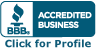

In [ ]:
scrapped[0]

In [ ]:
text_data = [(url, get_data(soup)) for url, soup in scrapped]

In [ ]:
df = pd.DataFrame([{"url": url, "title": features[0], "n_headers": features[1], "channel": features[2], "n_images": features[3], "n_videos": features[4], "n_paragraphs": features[5], "text": features[6]} for url, features in text_data])
df.head()

,url,title,n_headers,channel,n_images,n_videos,n_paragraphs,text
0,http://mashable.com/2014/05/28/google-employee...,"Google's Employee Demographics: Mostly White, ...",0,,4,1,1,\nGoogle released demographic data on its near...
1,http://mashable.com/2013/03/05/getgoing/,GetGoing Promises Big Flight Discounts if You ...,0,,4,1,1,\nThe Launchpad is a series that introduces Ma...
2,http://mashable.com/2014/02/05/new-apple-paten...,New Apple Patents Hint at Solar-Powered Devices,0,,3,1,1,\nApple may be going green in the next few yea...
3,http://mashable.com/2014/02/22/questions-accep...,5 Questions to Ask Yourself Before Accepting a...,0,,3,1,1,\nMany job seekers are inclined to jump at the...
4,http://mashable.com/2013/12/30/marketers-faceb...,Marketers Learn to Play by Facebook's Changing...,0,,3,1,1,"\nWhen Sim Partners, a provider of local and s..."


In [ ]:
df = df[df["title"] != ""].reset_index()
print(df.loc[0, "text"])


Google released demographic data on its nearly 50,000 employees for the first time Wednesday.The gist: Google employees are predominantly men (70%) and predominantly white (61%).[seealso slug="you-are-not-a-princess-ad"]"Google is not where we want to be when it comes to diversity," Laszlo Bock, Google's senior vice-president of people operations, wrote in a blog post, "And it’s hard to address these kinds of challenges if you’re not prepared to discuss them openly, and with the facts."The gender data shared is global for all Google's 50,000 employees, while the ethnicity data is strictly for the company's U.S. employees. Overall, 70% of Google employees are male, and 91% of U.S. employees are either white or Asian. Google's leadership is even less diverse: 79% of Google's leadership is male, while 72% of its leadership is white.





Credit: Google


The data reinforces a gender stereotype common among Silicon Valley tech companies, where men tend to dominate the tech industry; this 

In [ ]:
dc_content = [text_features(url, features[-1]) for url, features in text_data]
df_content = pd.concat(dc_content).groupby("url").agg(["mean", "min", "max", "count"])
dc_title = [text_features(url, features[0]) for url, features in text_data]
df_title = pd.concat(dc_title).groupby("url").agg(["mean", "count"])

In [ ]:
df_title = df_title[[(x, y) for x, y in df_title.columns if y != "count"] + [("n_words", "count")]]
df_title.columns = ["title_" + "_".join(x) for x in df_title.columns]
df_title = df_title.rename(columns={"title_n_words_count": "title_n_sentences"}).reset_index()

In [ ]:
df_content = df_content[[(x, y) for x, y in df_content.columns if y != "count"] + [("n_words", "count")]]
df_content.columns = ["content_" + "_".join(x) for x in df_content.columns]
df_content = df_content.rename(columns={"content_n_words_count": "content_n_sentences"}).reset_index()

In [ ]:
df_final = reduce(lambda left,right: pd.merge(left,right,on='url'), [df, df_title, df_content])

In [ ]:
df_final.drop(['index'],axis=1,inplace=True)

In [ ]:
df_final = reduce(lambda left,right: pd.merge(left,right,on='url'), [aux[['url','shares']], df_final])

In [ ]:
del df, df_title, df_content, dc_title, dc_content, text_data, scrapped

In [ ]:
titles = " ".join(df_final["title"].str.lower())

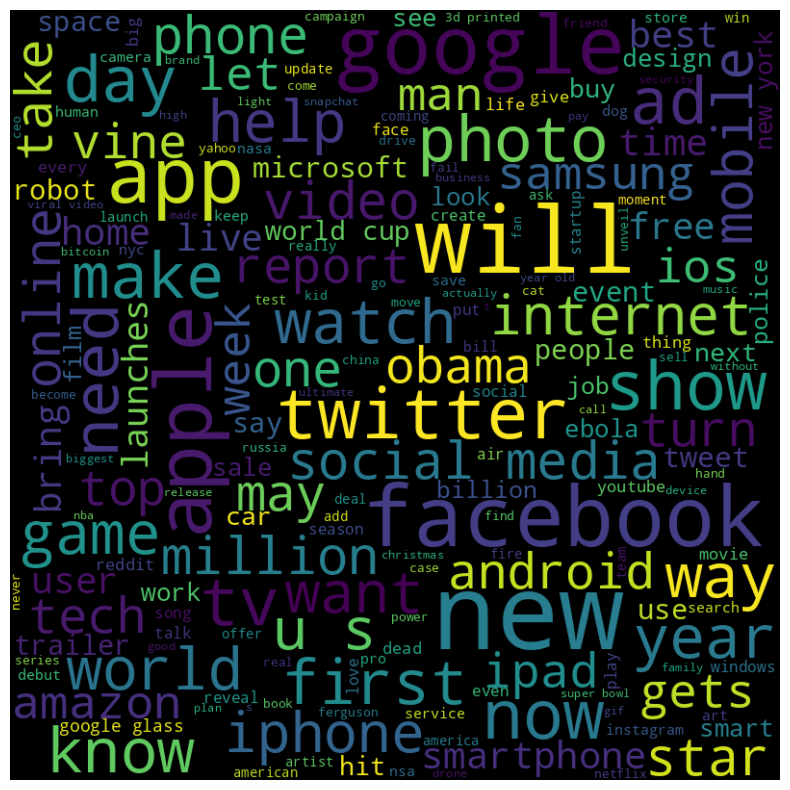

In [ ]:
generate_wordcloud(titles)

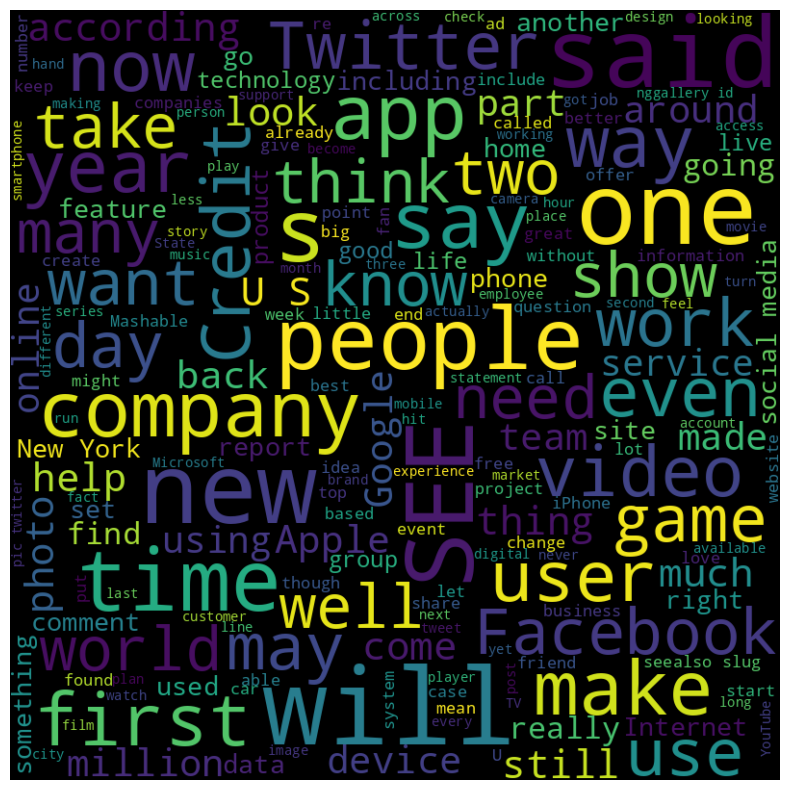

In [ ]:
generate_wordcloud(" ".join(df_final["text"]))

In [ ]:
df_final["text_cleaned"] = df_final["text"].str.replace("\n", "").map(clean_text).map(word_tokenize).str.join(" ")

In [ ]:
df_final.to_pickle("../03_Data/online_news_scrapped.pkl")

**Ingenieria de datos**

In [ ]:
vect = TfidfVectorizer(min_df=0.1, ngram_range=(1,2), stop_words=stopwords.words("english"))
words = pd.DataFrame(data=vect.fit_transform(df_final["text_cleaned"]).todense(), columns=[f"content_{x}" for x in vect.get_feature_names_out()])

In [ ]:
df_final = df_final.join(words)

In [ ]:
df_final["len_title"] = df_final["title"].str.len()
df_final["n_words_title"] = df_final["title"].str.split(" ").str.len()
df_final["avg_len_words_title"] = df_final["title"].str.split(" ").map(lambda x:np.mean([x for x in map(len, x)]))
df_final["len_content"] = df_final["text"].str.len()
df_final["n_words_content"] = df_final["text"].str.split(" ").str.len()
df_final["avg_len_words_content"] = df_final["text"].str.split(" ").map(lambda x:np.mean([x for x in map(len, x)]))

In [ ]:
X = df_final[[x for x in df_final.columns if x not in ["index", "url", "title", "text", "shares", "text_cleaned","level_0","channel"]]]
y = df_final[["shares"]]

In [ ]:
y.describe()

,shares
count,2000.00
mean,16.77
std,46.40
min,0.06
25%,2.49
50%,5.22
75%,13.34
max,912.70


In [ ]:
y.loc[y['shares'] < 20,'shares'] = 0
y.loc[y['shares'] >= 20,'shares'] = 1

In [ ]:
y.value_counts()

shares
0.00      1650
1.00       350
Name: count, dtype: int64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, random_state=333)

#### Modelación

**<span style="color:red">R2</span>** Los hiperparámetros principales en RF son:

- `n_estimators`: Número de árboles en el bosque.

- `max_depth`: La máxima profundidad del árbol. Si `None`, los nodos se expanden hasta que todas las hojas contengan menos que `min_samples_split` muestras.

- `min_samples_split`: Número mínimo de muestras necesarias para dividir un nodo interno. Puede ser un número entero (considera ese número exacto) o flotante (fracción del total de muestras).

- `min_samples_leaf`: Número mínimo de muestras que debe tener una hoja. Al igual que `min_samples_split`, puede ser un entero o un flotante.

- `max_features`: El número de características a considerar al buscar la mejor división. Puede ser:
  - `'sqrt'`: `max_features=sqrt(n_features)`
  - `'log2'`: `max_features=log2(n_features)`

In [ ]:
# Espacio hiperparametral
space = {
    'n_estimators': hp.choice('n_estimators', np.arange(50, 501, 50, dtype=int)),
    'max_depth': hp.choice('max_depth', np.arange(5, 31, 1, dtype=int)),
    'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.5),
    'min_samples_leaf': hp.uniform('min_samples_leaf', 0.01, 0.5),
    'max_features': hp.choice('max_features', ['sqrt', 'log2'])  # Aquí cambiamos 'auto' por 'sqrt'
}

def objective(params):
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds)
    return {'loss': 1 - f1, 'status': STATUS_OK}

trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=100, trials=trials)
best_params = space_eval(space, best)

print("Mejores parámetros:", best_params)

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 100/100 [00:51<00:00,  1.93trial/s, best loss: 1.0]
Mejores parámetros: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 0.3849583145285065, 'min_samples_split': 0.21103390551005866, 'n_estimators': 250}


In [ ]:
rfr = RandomForestClassifier(**best_params)
rfr.fit(X_train, y_train)

RandomForestClassifier(max_depth=9, min_samples_leaf=0.3849583145285065,
                       min_samples_split=0.21103390551005866, n_estimators=250)

**<span style="color:red">R3</span>**

In [ ]:
get_cv_scores_report_classification(rfr,X_test,y_test,5)

Precision en CV: mean 0.66, std 0.00
Recall en CV: mean 0.81, std 0.00
F1 en CV: mean 0.73, std 0.00


In [ ]:
pd.to_pickle(rfr,'../02_Codes/01_Models/rfr.pkl')

In [ ]:
rfr = pd.read_pickle('../02_Codes/01_Models/rfr.pkl')